In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
df = pd.read_csv("/kaggle/input/datasets/harshadapatil31/student-performance-and-study-habits-dataset/student_performance_dataset.csv")
df.shape

(1000, 12)

In [3]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [5]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


Key Insights:
* Study Time: Varies from a minimum of 0.5 hours (30 minutes) to a maximum of 8.1 hours.
* Attendance: Ranges from 54.8% to a perfect 100%.
* Sleep: Students get between 3.2 and 10 hours of sleep.
* Score Floor: The lowest score rose significantly, moving from 31.3% in previous grades to 46.8% on the final exam.
* Score Ceiling: The maximum score achieved remained at 100% for both previous grades and the final exam.
* Average Performance: Class averages saw a noticeable upward shift, increasing from roughly 69.7% to 83.5%.

#### Incase of NA values of parental education, "Unknown" is used.

In [6]:
df['parental_education'] = df['parental_education'].fillna("Unknown")

Identifying categorical columns and using label encoder 

In [7]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols

['gender',
 'parental_education',
 'internet_access',
 'extracurricular_activities',
 'part_time_job',
 'final_grade']

In [8]:
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

### EDA

#### 1. Grade Distribution

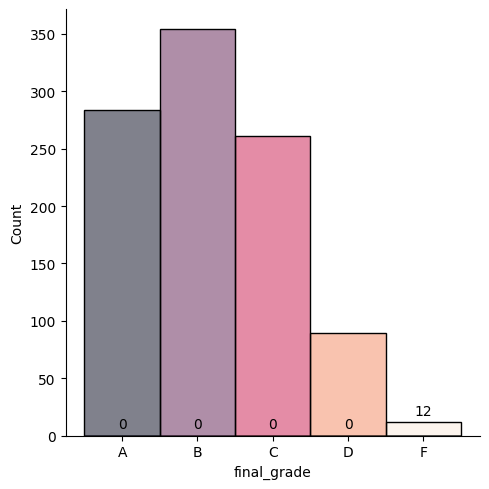

In [9]:
g = sns.displot(df,x='final_grade',binwidth=1,discrete=True,palette='rocket',hue='final_grade', legend=False)
g.set(xticks=[0, 1, 2, 3, 4], xticklabels=['A', 'B', 'C', 'D', 'F'])
for ax in g.axes.flat:
    ax.bar_label(ax.containers[0], padding=3)
plt.show()

#### 2. grade vs attendence

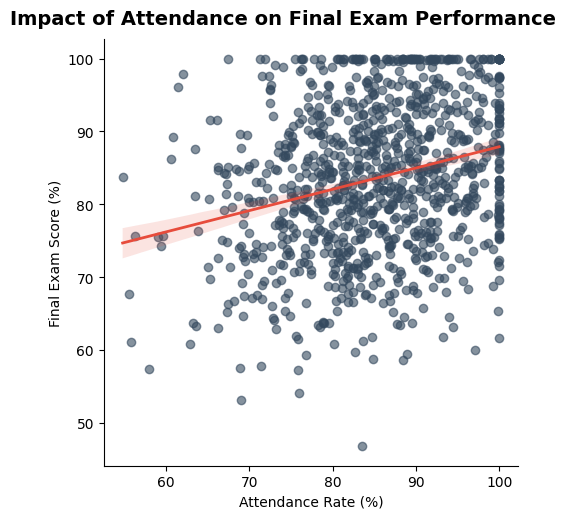

In [10]:
g = sns.lmplot(data=df, x="attendance_percent", y="final_exam_score",
              scatter_kws={'alpha': 0.6, 'color': '#34495e'},  # Softens the points to handle overlap
            line_kws={'color': '#e74c3c', 'linewidth': 2},
              )
g.set_axis_labels("Attendance Rate (%)", "Final Exam Score (%)")
g.fig.suptitle("Impact of Attendance on Final Exam Performance", y=1.03, fontsize=14, fontweight='bold')

plt.show()

#### 3. Study Time vs Performance

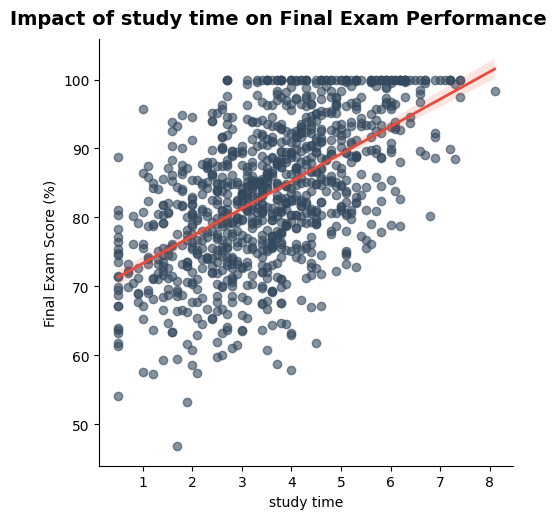

In [11]:
g = sns.lmplot(data=df, x="study_time_hours", y="final_exam_score",
              scatter_kws={'alpha': 0.6, 'color': '#34495e'},  # Softens the points to handle overlap
            line_kws={'color': '#e74c3c', 'linewidth': 2},
              )
g.set_axis_labels("study time", "Final Exam Score (%)")
g.fig.suptitle("Impact of study time on Final Exam Performance", y=1.03, fontsize=14, fontweight='bold')

plt.show()

#### 4. Sleep Distribution by Grade

/tmp/ipykernel_16/1446842219.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


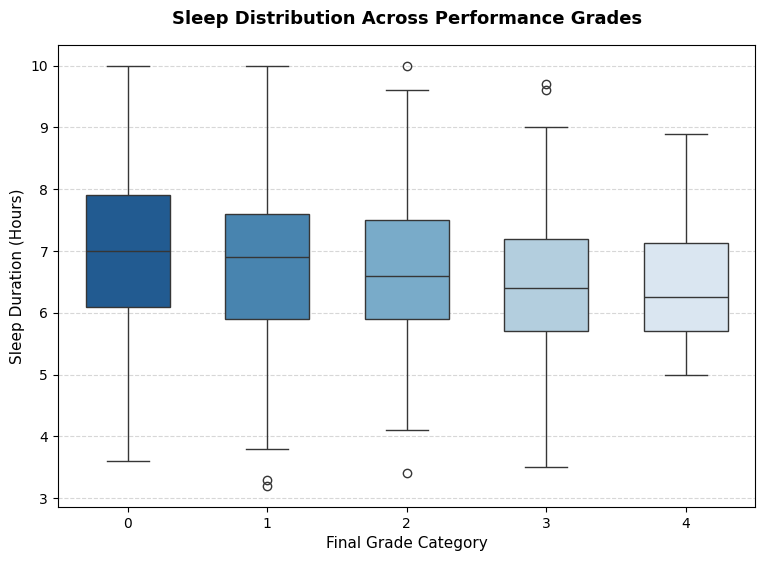

In [12]:
plt.figure(figsize=(9, 6))
ax = sns.boxplot(
    data=df,
    x='final_grade',
    y='sleep_hours',
    palette='Blues_r',
    width=0.6
)

# Style adjustments
ax.set_title("Sleep Distribution Across Performance Grades", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Final Grade Category", fontsize=11)
ax.set_ylabel("Sleep Duration (Hours)", fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

#### 4. Part-time Job vs At-Risk Rate

In [13]:
df['at_risk'] = df['final_grade'].isin([3,4]).astype('int') 
at_risk_rates = df.groupby('part_time_job')['at_risk'].mean() *100

In [14]:
at_risk_rates

part_time_job
0     6.725146
1    17.405063
Name: at_risk, dtype: float64

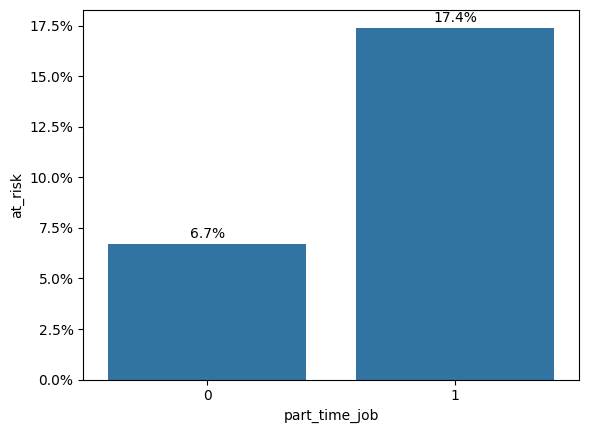

In [15]:
ax = sns.barplot(data=df,
                x='part_time_job',
                y= df['at_risk']*100,
                errorbar=None
                )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(100.0))

ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=2)

plt.show()